# Stellar Class (S6E6) — EDA

3-class classification (GALAXY / QSO / STAR), metric = **Balanced Accuracy**. Figures saved to `reports/figures/`; written conclusions in `reports/EDA_FINDINGS.md`.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
import sys; sys.path.insert(0, '..')
from src import data as D, features as F
FIG = Path('../reports/figures'); FIG.mkdir(parents=True, exist_ok=True)
sns.set_theme(style='whitegrid')
tr = D.load_train(); te = D.load_test()
print('train', tr.shape, 'test', te.shape)
tr.head()

train (577347, 12) test (247435, 11)


,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,GALAXY
1,1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,GALAXY
2,2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,QSO
3,3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,GALAXY
4,4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,GALAXY


## 1. Target distribution

class
GALAXY    377480
QSO       117143
STAR       82724
Name: count, dtype: int64
class
GALAXY    0.6538
QSO       0.2029
STAR      0.1433
Name: count, dtype: float64


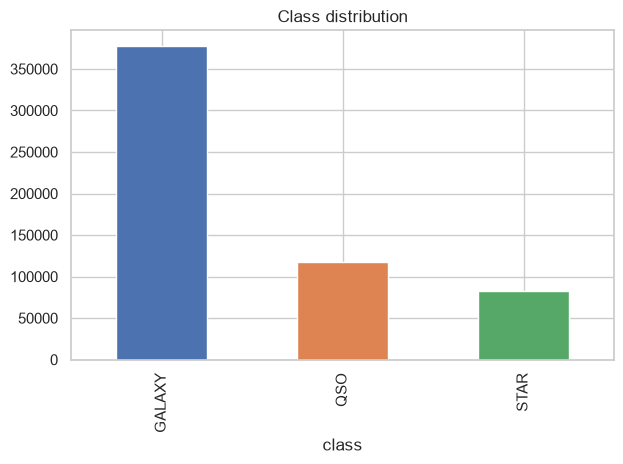

In [2]:
vc = tr[D.TARGET].value_counts()[D.CLASSES]
print(vc); print((vc/len(tr)).round(4))
ax = vc.plot.bar(color=['#4C72B0','#DD8452','#55A868']); ax.set_title('Class distribution')
plt.tight_layout(); plt.savefig(FIG/'class_distribution.png', dpi=110); plt.show()

## 2. Missing values & sentinels (data is clean)

In [3]:
print('train NaNs:', int(tr.isna().sum().sum()), ' test NaNs:', int(te.isna().sum().sum()))
print(tr[D.NUMERIC_COLS].describe().T[['min','max']])

train NaNs: 0  test NaNs: 0


                min         max
alpha      0.011684  359.999810
delta    -17.966988   79.158322
u         -0.139225   28.253263
g         13.535483   27.620208
r         12.579407   25.254499
i         11.962781   27.910853
z         11.682803   26.826867
redshift  -0.009970    7.010780


## 3. Numeric features by class (redshift is the key separator)

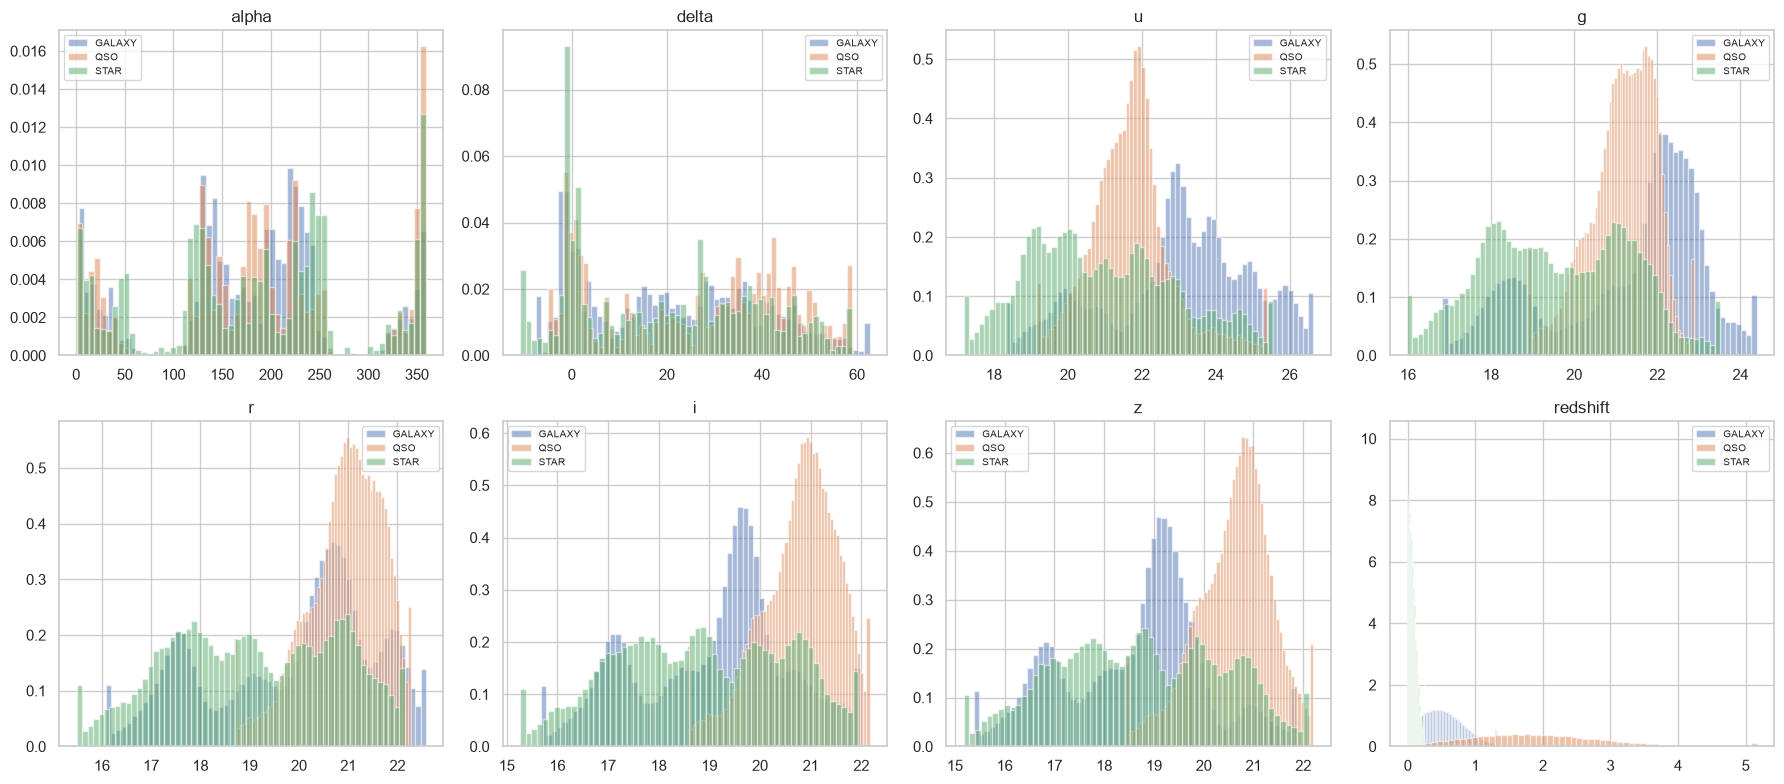

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, c in zip(axes.ravel(), D.NUMERIC_COLS):
    for cls in D.CLASSES:
        s = tr.loc[tr[D.TARGET]==cls, c]
        clip = s.clip(s.quantile(.01), s.quantile(.99))
        ax.hist(clip, bins=60, alpha=.5, density=True, label=cls)
    ax.set_title(c); ax.legend(fontsize=7)
plt.tight_layout(); plt.savefig(FIG/'numeric_by_class.png', dpi=110); plt.show()

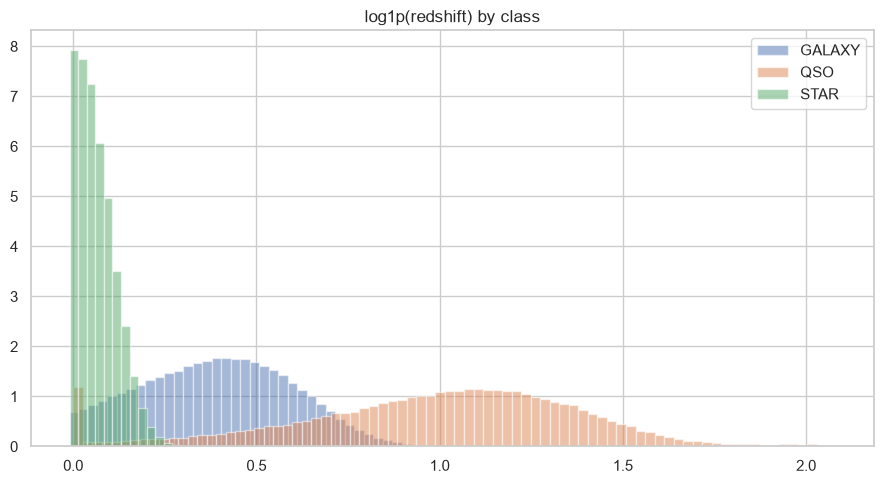

           count   mean    std   min    25%    50%    75%    max
class                                                           
GALAXY  377480.0  0.509  0.309 -0.01  0.267  0.482  0.715  6.860
QSO     117143.0  1.876  1.070  0.00  1.132  1.799  2.506  7.011
STAR     82724.0  0.068  0.064 -0.01  0.022  0.056  0.102  5.445


In [5]:
# redshift on log1p scale, by class
fig, ax = plt.subplots(figsize=(9,5))
for cls in D.CLASSES:
    ax.hist(np.log1p(tr.loc[tr[D.TARGET]==cls,'redshift'].clip(lower=-0.999)),
            bins=80, alpha=.5, density=True, label=cls)
ax.set_title('log1p(redshift) by class'); ax.legend()
plt.tight_layout(); plt.savefig(FIG/'redshift_by_class.png', dpi=110); plt.show()
print(tr.groupby(D.TARGET)['redshift'].describe().round(3))

## 4. Categorical features vs class


== spectral_type ==
 class          GALAXY    QSO   STAR
spectral_type                      
A/F             0.198  0.504  0.298
G/K             0.568  0.193  0.240
M               0.950  0.013  0.038
O/B             0.083  0.711  0.206


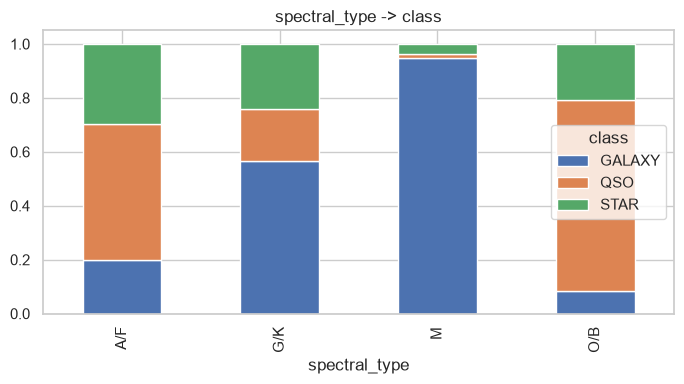


== galaxy_population ==
 class              GALAXY    QSO   STAR
galaxy_population                      
Blue_Cloud          0.345  0.420  0.235
Red_Sequence        0.903  0.028  0.069


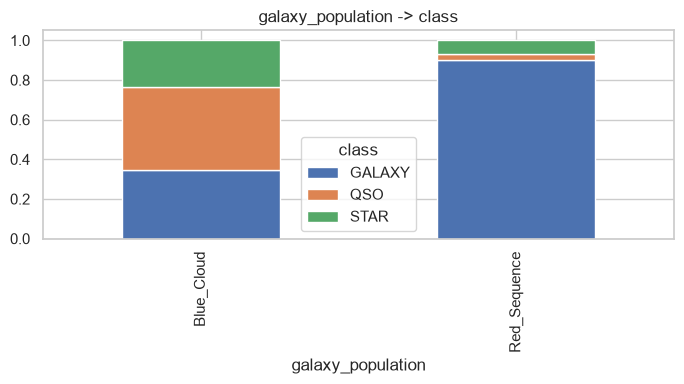

In [6]:
for c in D.CATEGORICAL_COLS:
    ct = pd.crosstab(tr[c], tr[D.TARGET], normalize='index')[D.CLASSES]
    print('\n==', c, '==\n', ct.round(3))
    ct.plot.bar(stacked=True, figsize=(7,4), title=f'{c} -> class')
    plt.tight_layout(); plt.savefig(FIG/f'cat_{c}.png', dpi=110); plt.show()

## 5. Engineered color-index separation

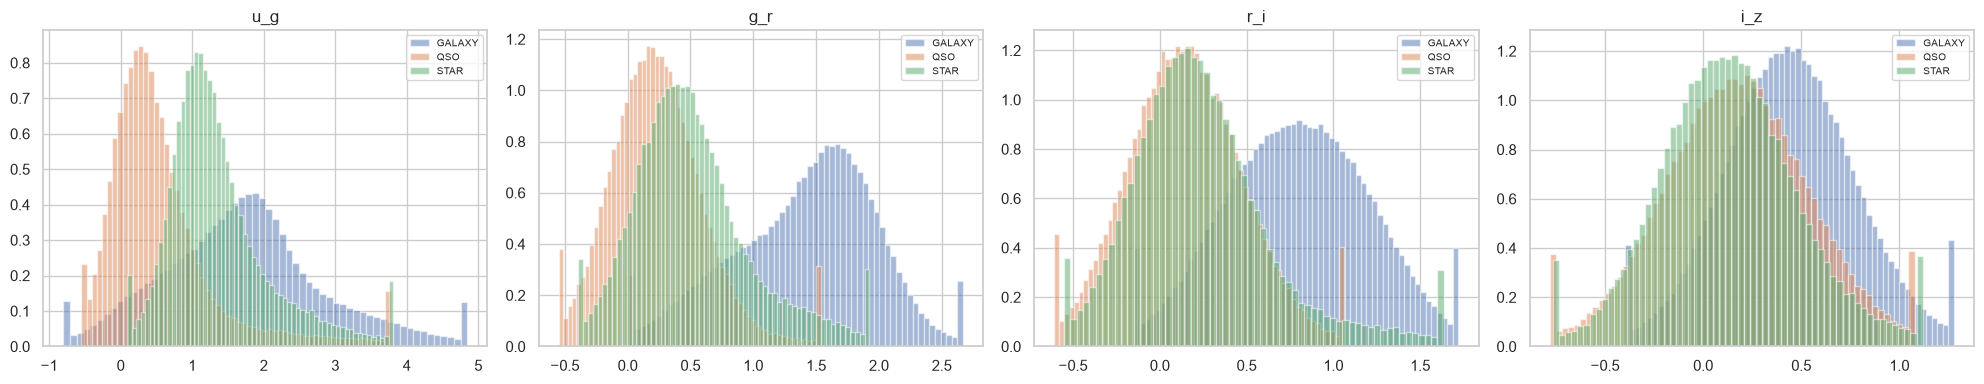

In [7]:
Xtr = F.add_features(tr)
fig, axes = plt.subplots(1, 4, figsize=(20,4))
for ax, c in zip(axes, F.COLOR_COLS):
    for cls in D.CLASSES:
        s = Xtr.loc[tr[D.TARGET]==cls, c]
        ax.hist(s.clip(s.quantile(.01), s.quantile(.99)), bins=60, alpha=.5, density=True, label=cls)
    ax.set_title(c); ax.legend(fontsize=7)
plt.tight_layout(); plt.savefig(FIG/'colors_by_class.png', dpi=110); plt.show()

## 6. Correlation of numeric features

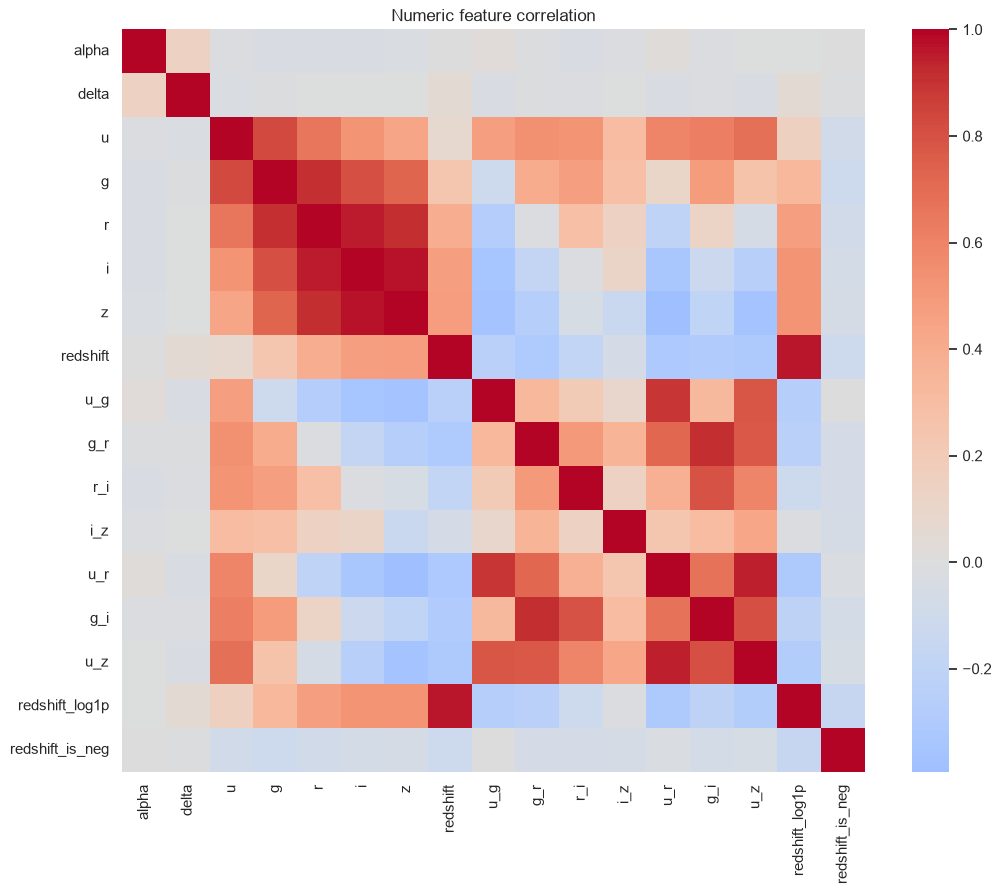

In [8]:
corr = Xtr[F.NUMERIC_FEATURES].corr()
plt.figure(figsize=(11,9)); sns.heatmap(corr, cmap='coolwarm', center=0, square=True)
plt.title('Numeric feature correlation'); plt.tight_layout()
plt.savefig(FIG/'correlation.png', dpi=110); plt.show()

## 7. Train vs test distribution sanity (no drift expected)

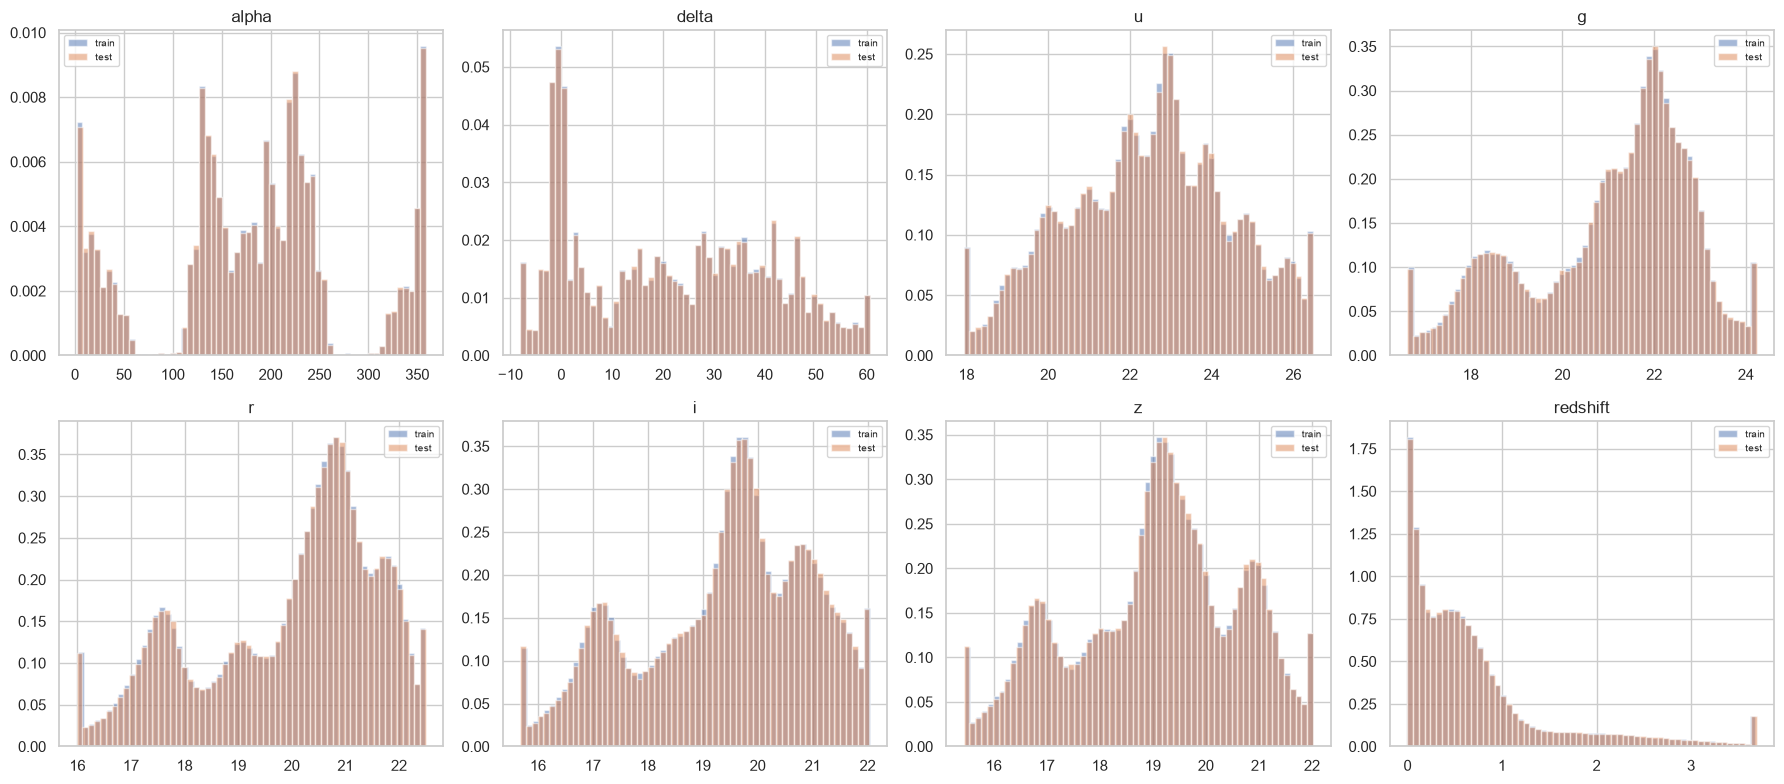

In [9]:
fig, axes = plt.subplots(2,4, figsize=(18,8))
for ax, c in zip(axes.ravel(), D.NUMERIC_COLS):
    ax.hist(tr[c].clip(tr[c].quantile(.01),tr[c].quantile(.99)), bins=60, alpha=.5, density=True, label='train')
    ax.hist(te[c].clip(te[c].quantile(.01),te[c].quantile(.99)), bins=60, alpha=.5, density=True, label='test')
    ax.set_title(c); ax.legend(fontsize=7)
plt.tight_layout(); plt.savefig(FIG/'train_vs_test.png', dpi=110); plt.show()